# Fine-Tuning Gemma 2 for Bengali Poetry Generation

## Overview

This notebook demonstrates the process of fine-tuning **Gemma 2** for generating Bengali poetry based on specific poets, titles, and categories. The target is to model the stylistic and thematic characteristics of various Bengali poets, empowering the generation of culturally sensitive literary outputs.

This work is part of the effort to adapt AI language models to support underrepresented languages and cultural contexts, and it focuses on Bengali, one of the 73 eligible languages for this competition.

### Objectives

1. **Dataset Creation**: Curate a high-quality dataset of Bengali poems, organized by poet, category, and poem content.
2. **Fine-tuning Strategy**: Apply efficient fine-tuning techniques using **LoRA (Low-Rank Adaptation)** and **quantization** to handle model parameters effectively while preserving performance.
3. **Inference & Evaluation**: Generate Bengali poems in the style of selected poets and evaluate the fluency, accuracy, and cultural alignment of the outputs.

## Dataset Creation/Curation

### Source of Data

The dataset used for fine-tuning is a curated collection of Bengali poems sourced from the [Bengali Poem Dataset](https://github.com/shuhanmirza/Bengali-Poem-Dataset). Each poem in this dataset is organized by poet and includes metadata about its literary category. This ensures that the model can learn not only the language but also nuances such as tone, style, and thematic content.

In [ ]:
!git clone https://github.com/shuhanmirza/Bengali-Poem-Dataset.git
%cd /kaggle/working/Bengali-Poem-Dataset

### Data Processing and Structure

To facilitate fine-tuning, the dataset was processed using a Python script that walks through the directory structure of the dataset. Each poet’s directory contains individual poem files, and additional metadata, such as the **CLASS.txt** file, is used to classify the poems by category (e.g., love, nature, etc.). The final dataset is organized into the following structure:
- **Poet**: The name of the poet (e.g., Rabindranath Tagore).
- **Category**: The literary category (e.g., love, nature).
- **Title**: The title of the poem.
- **Poem**: The full text of the poem.

The dataset is then compiled into a CSV file for easier loading into the fine-tuning pipeline.

In [ ]:
import os
import pandas as pd

# Define the directory where the dataset is stored
dataset_dir = 'dataset'

# Create an empty list to store the data
data = []

# Walk through the directory structure
for poet in os.listdir(dataset_dir):
    poet_dir = os.path.join(dataset_dir, poet)
    if os.path.isdir(poet_dir):  # Check if it's a directory (i.e., a poet's folder)
        for poem in os.listdir(poet_dir):
            poem_dir = os.path.join(poet_dir, poem)
            if os.path.isdir(poem_dir):  # Check if it's a directory (i.e., a poem's folder)
                class_text = None
                # First, look for the CLASS.txt file
                class_file_path = os.path.join(poem_dir, 'CLASS.txt')
                if os.path.exists(class_file_path):  # If CLASS.txt exists, read its content
                    with open(class_file_path, 'r', encoding='utf-8') as class_file:
                        class_text = class_file.read().strip()

                # Now process the poem files and skip CLASS.txt and SOURCE.txt
                for file in os.listdir(poem_dir):
                    if file.endswith('.txt') and file not in ['CLASS.txt', 'SOURCE.txt']:
                        file_path = os.path.join(poem_dir, file)
                        with open(file_path, 'r', encoding='utf-8') as f:
                            poem_text = f.read()  # Read the poem content
                            title = os.path.splitext(file)[0]  # Get the poem title (filename without extension)
                            # Append the poet, class, title, and poem text as a row in the data list
                            data.append({
                                'poet': poet,
                                'category': class_text,
                                'title': title,
                                'poem': poem_text
                            })

# Create a DataFrame from the list of dictionaries
df = pd.DataFrame(data)

# Save the DataFrame to a CSV file
df.to_csv('poems_dataset.csv', index=False, encoding='utf-8')
!mv /kaggle/working/Bengali-Poem-Dataset/poems_dataset.csv /kaggle/working/
%cd /kaggle/working/
df.head()

### Cultural Sensitivity and Representation

Great care has been taken to ensure that the dataset accurately reflects the cultural and literary heritage of Bengali poetry. Poems from iconic Bengali poets, such as Rabindranath Tagore, have been included with appropriate categorization to maintain the integrity of the genre. The metadata on literary categories ensures that the model captures not only linguistic fluency but also cultural nuances, such as tone, style, and thematic content.

## Fine-tuning Gemma

### Library Setup

We fine-tune the Gemma 2 model using the [Unsloth](https://github.com/unslothai/unsloth) library. Below, we install the necessary dependencies and [Weights & Biases](https://wandb.ai/site) for experiment tracking.

In [ ]:
%%capture
!pip install --upgrade --no-cache-dir wandb "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install --no-deps packaging ninja einops "flash-attn>=2.6.3"

from torch import __version__; from packaging.version import Version as V
xformers = "xformers==0.0.27" if V(__version__) < V("2.4.0") else "xformers"
!pip install --no-deps {xformers} trl peft accelerate bitsandbytes triton

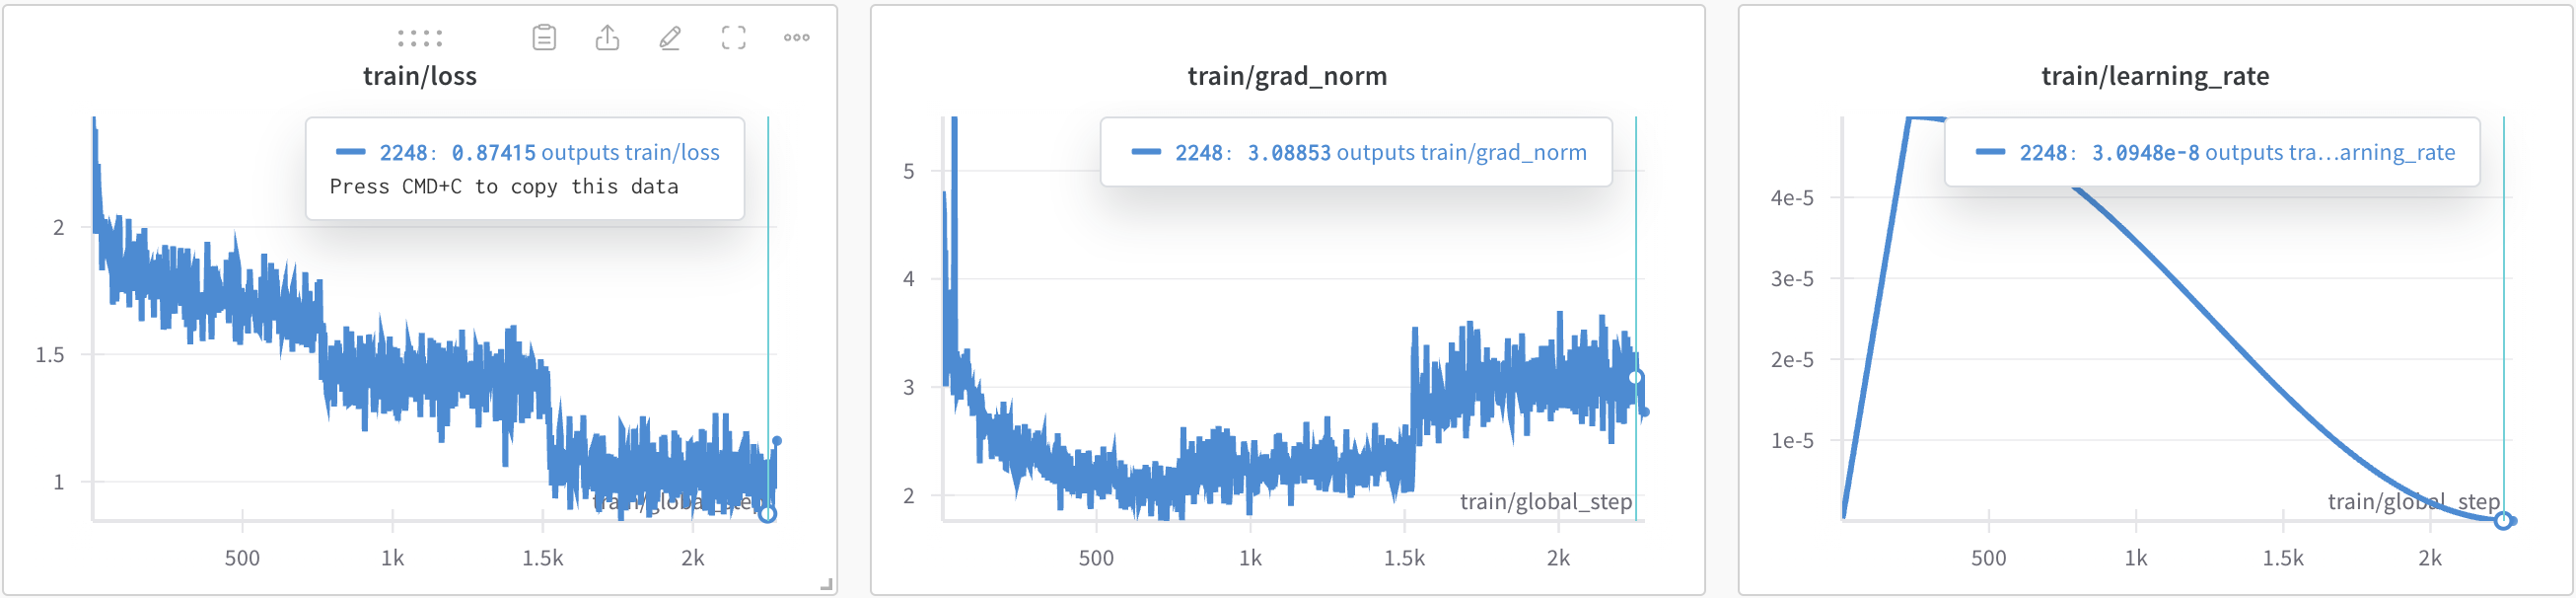

In [ ]:
from google.colab import userdata
secret_value = userdata.get("WANDB")

import wandb
wandb.login(key=secret_value)

### Model Architecture and Parameter Selection

- **Base Model**: `unsloth/gemma-2-9b`
  - The **Gemma 2 (9 billion parameters)** model provides a strong foundation for natural language generation tasks.
  - **Quantization**: 4-bit quantization reduces memory usage significantly, allowing us to train the model with lower computational overhead without sacrificing performance.
  - **LoRA (Low-Rank Adaptation)**: LoRA is used for continual pretraining, allowing us to fine-tune only specific layers (projection layers like `q_proj`, `k_proj`, etc. and layers like `embed_tokens`, `lm_head` for continual pretraining), making the training process more efficient.

In [ ]:
from unsloth import FastLanguageModel
import torch
max_seq_length = 2048
dtype = None # None for auto detection. Float16 for Tesla T4, V100, Bfloat16 for Ampere+
load_in_4bit = True # Use 4bit quantization to reduce memory usage.

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-2-9b",
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

#### LoRA Hyperparameters:

- **Rank (r)**: 64
  - The rank controls the size of the low-rank adaptation. A higher value enables better approximation of the full model parameters.
- **LoRA Alpha**: 32
  - Scaling factor for the LoRA updates. Usually set to half of Rank.
- **LoRA Dropout**: 0
  - Dropout is disabled as it is optimized for continual pretraining.

***Note***: *Due to size constraints, you'll get CUDA out of memory error from here in Kaggle Notebooks. The actual model variant was tuned outside in Google Colab Pro with A100 having 40 GB GPU RAM. [**Link to Training Notebook**](https://colab.research.google.com/drive/1HN11uDcaXtRyqOoKad6cByxNYshFGdMR?usp=sharing).*

In [ ]:
model = FastLanguageModel.get_peft_model(
    model,
    r = 64,
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",
                      "embed_tokens", "lm_head"], # Add for continual pretraining
    lora_alpha = 32,
    lora_dropout = 0, # Supports any, but = 0 is optimized
    bias = "none",    # Supports any, but = "none" is optimized
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for very long context
    random_state = 3407,
    use_rslora = True,
    loftq_config = None,
)

### Prompt Design

In [ ]:
prompt = """You are tasked with writing a poem related to the title in the style of the poet mentioned below. The poem should fit the specified category and adhere to the poet's distinctive tone, language, and themes.

### Title:
{}

### Poet:
{}

### Category:
{}

### Poem:
{}"""

EOS_TOKEN = tokenizer.eos_token
def formatting_prompts_func(examples):
    titles    = examples["title"]
    poets     = examples["poet"]
    categorys = examples["category"]
    poems     = examples["poem"]
    texts = []
    for title, poet, category, poem in zip(titles, poets, categorys, poems):
        # Must add EOS_TOKEN, otherwise your generation will go on forever!
        text = prompt.format(title, poet, category, poem) + EOS_TOKEN
        texts.append(text)
    return { "text" : texts, }
pass

from datasets import load_dataset
dataset = load_dataset("csv", data_files="/kaggle/working/poems_dataset.csv", split="train")
dataset = dataset.map(formatting_prompts_func, batched = True,)

### Training Setup

We leverage **`UnslothTrainer`**, a custom trainer. The training is performed on GPU (NVIDIA A100-SXM4-40GB), where **bfloat16** is auto-detected based on hardware capabilities.

#### Training Parameters:

- **Learning Rate**:
  - **Base learning rate**: 5e-5 for the main model layers.
  - **Embedding layer learning rate**: 1e-5 to ensure the word embeddings are fine-tuned more cautiously.
- **Scheduler**: `cosine`
  - A cosine learning rate schedule allows for smoother learning rate decay, preventing abrupt model parameter changes.

In [ ]:
from transformers import TrainingArguments
from unsloth import is_bfloat16_supported
from unsloth import UnslothTrainer, UnslothTrainingArguments

trainer = UnslothTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset,
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    dataset_num_proc = 2,

    args = UnslothTrainingArguments(
        report_to = "wandb",
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_ratio = 0.1,
        num_train_epochs = 3,
        learning_rate = 5e-5,
        embedding_learning_rate = 1e-5,
        fp16 = not is_bfloat16_supported(),
        bf16 = is_bfloat16_supported(),
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "cosine",
        seed = 3407,
        output_dir = "outputs",
    ),
)

In [ ]:
trainer_stats = trainer.train()

### Model Publishing

The fine-tuned model is published to **Hugging Face** with a merged 16-bit weight format to optimize for inference. The model is available in Kaggle Models as well here: **https://www.kaggle.com/models/rishirajacharya/gemma-poetry-bn**

In [ ]:
model.push_to_hub_merged("rishiraj/gemma-poetry-bn", tokenizer, save_method = "merged_16bit", token = "")

## Inference and Evaluation

For inference, we use the fine-tuned model to generate Bengali poems by providing a title, poet, and category as inputs. The model generates poems in the style of the specified poet, respecting the cultural and thematic nuances of Bengali poetry.

### Evaluation Metrics

We evaluate the generated poems based on:
1. **Language Fluency**: Does the poem align with the natural flow and grammatical rules of Bengali?
2. **Cultural and Stylistic Alignment**: Does the poem reflect the intended poetic style, themes, and tone?
3. **Diversity of Outputs**: Does the model avoid repetition and generate diverse, high-quality outputs?

In [ ]:
FastLanguageModel.for_inference(model)
inputs = tokenizer(
[
    prompt.format(
        "অমন   আড়াল দিয়ে লুকিয়ে গেলে চলবে না।",
        "রবীন্দ্রনাথ ঠাকুর",
        "ভক্তিমূলক",
        "", # output
    )
], return_tensors = "pt").to("cuda")

outputs = model.generate(**inputs, max_new_tokens = 64, repetition_penalty = 1, use_cache = True)
tokenizer.batch_decode(outputs)